<a href="https://colab.research.google.com/github/ravindyaparami/Statistical-Learning-e20056/blob/main/E20056_fundamentals_of_probability_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q1) The Probability of Shooting at a Target

A point is chosen at random from a disk of radius $10$. Let $A$ be the event that the point lies within $1$ unit of the boundary.

1. Model the experiment assuming the point is uniformly distributed with respect to area, and compute $P(A)$.
2. Model the experiment assuming the distance to the point from the center is chosen uniformly from $[0,10]$, and the direction is chosen independently and uniformly from $[0,2\pi)$ and compute $P(A)$.
3. Explain why the two answers differ.


In [ ]:
#1
import numpy as np
import matplotlib.pyplot as plt

# Uniform distribution with respect to AREA

N = 1000000   # number of random samples

# Generate radius correctly for uniform area distribution
# r = R*sqrt(U)
u = np.random.rand(N)
r1 = 10 * np.sqrt(u)

# Generate angle uniformly
theta1 = 2 * np.pi * np.random.rand(N)

# Event A: point lies within 1 unit of boundary
# i.e., 9 <= r <= 10
A1 = (r1 >= 9)

# Estimated probability
P1 = np.mean(A1)

print("Model 1: Uniform with respect to area")
print("Estimated Probability =", P1)
print("Theoretical Probability = 0.19")

Model 1: Uniform with respect to area
Estimated Probability = 0.190089
Theoretical Probability = 0.19


In [ ]:
#2
# Radius uniformly distributed in [0,10]

# Radius directly uniform
r2 = 10 * np.random.rand(N)

# Angle uniform
theta2 = 2 * np.pi * np.random.rand(N)

# Event A
A2 = (r2 >= 9)

# Estimated probability
P2 = np.mean(A2)

print("\nModel 2: Uniform radius distribution")
print("Estimated Probability =", P2)
print("Theoretical Probability = 0.10")


Model 2: Uniform radius distribution
Estimated Probability = 0.099966
Theoretical Probability = 0.10


3.
The two models define different probability distributions over the disk.

###Model 1: Uniform with Respect to Area

In this model, Equal areas have equal probability.
Larger rings contain more area.
Outer regions of a disk occupy more physical space than inner regions.

The area element in polar coordinates is: dA=rdrdθ

This means probability density naturally increases with radius because circumference grows as: 2πr

Hence points near the boundary are more likely. That is why the probability becomes: 0.19


###Model 2: Uniform Radius

Here: r∼U(0,10)

Every radius interval of equal width is equally probable.

So The interval [0,1] and the interval [9,10]have the same probability.

This ignores the fact that outer rings contain much larger area.

Therefore, this model places relatively too much probability near the center and too little near the boundary.

Hence: P(A)=0.10

# Q2) Bertrand's Paradox

A chord of a circle is chosen “at random.” What is the probability that its length exceeds the side length of the inscribed equilateral triangle?

Show that different mathematically natural models of “random chord” lead to different answers.

In [ ]:
import numpy as np

N = 100000
R = 1

# Model 1: Random midpoint uniformly in disk

u = np.random.rand(N)
r = np.sqrt(u) * R

prob1 = np.mean(r < R/2)

print("Model 1 Probability =", prob1)


# Model 2: Uniform distance along radius

r2 = np.random.rand(N) * R

prob2 = np.mean(r2 < R/2)

print("Model 2 Probability =", prob2)


# Model 3: Random endpoint

theta = np.random.rand(N) * np.pi

prob3 = np.mean(theta > np.pi/3)

print("Model 3 Probability =", prob3)

Model 1 Probability = 0.25009
Model 2 Probability = 0.49968
Model 3 Probability = 0.66611


#Q8) Probability of Being a Girl?

A family has two children. Assume each child is equally likely to be a boy or a girl, independently of the other.

What is the probability that both children are girls, given that **at least one** of them is a girl?

In [ ]:
# sample space
sample_space = ['BB','BG','GB','GG']

# Event A: both girls
A = ['GG']

# Event B: at least one girl
B = [x for x in sample_space if 'G' in x]

# probabilities
P_A_and_B = len(set(A).intersection(set(B))) / len(sample_space)
P_B = len(B) / len(sample_space)

# Bayes theorem
P_A_given_B = P_A_and_B / P_B

print("P(A ∩ B) =", P_A_and_B)
print("P(B) =", P_B)
print("P(A | B) =", P_A_given_B)

P(A ∩ B) = 0.25
P(B) = 0.75
P(A | B) = 0.3333333333333333


# Q9) Information Available in a Discrete Random Variable

A factory inspects a product and records its quality using two different coding systems.

Each product falls into exactly one of the following four categories:

* $G_1$: good quality, produced on Machine 1
* $G_2$: good quality, produced on Machine 2
* $D_1$: defective, produced on Machine 1
* $D_2$: defective, produced on Machine 2

Assume the sample space is

$$
\Omega=\{G_1,G_2,D_1,D_2\},
$$

with probabilities

$$
P(\{G_1\})=0.50,\qquad P(\{G_2\})=0.20,\qquad P(\{D_1\})=0.10,\qquad P(\{D_2\})=0.20.
$$

Define two discrete random variables on the same probability space:

* $X$ records only whether the item is good or defective:
  $$
  X(G_1)=0,\quad X(G_2)=0,\quad X(D_1)=1,\quad X(D_2)=1.
  $$

* $Y$ records both quality and machine:
  $$
  Y(G_1)=1,\quad Y(G_2)=2,\quad Y(D_1)=3,\quad Y(D_2)=4.
  $$

Answer the following.

1. Write down the probability space $(\Omega,\mathfrak F,P)$, where $\mathfrak F=\mathfrak P(\Omega)$.

2. Compute the $\sigma$-algebra generated by $X$, namely $\sigma(X)$.

3. Compute the $\sigma$-algebra generated by $Y$, namely $\sigma(Y)$.

4. Show that $\sigma(X)\subseteq \sigma(Y)$, and explain why $Y$ contains more information than $X$.

5. Find the marginal distribution of $X$.

6. Find the marginal distribution of $Y$.

7. Compute the joint probabilities
   $$
   P(X=0,Y=1),\quad P(X=0,Y=2),\quad P(X=1,Y=3),\quad P(X=1,Y=4).
   $$

8. Compute the conditional probabilities
   $$
   P(X=1\mid Y=3),\qquad P(X=1\mid Y=4),\qquad P(Y=3\mid X=1),\qquad P(Y=4\mid X=1).
   $$

9. Interpret the difference between conditioning on $X$ and conditioning on $Y$.

10. Explain, in words, what information is available in $\sigma(X)$ but not in $\sigma(Y)$, and what information is available in $\sigma(Y)$ but not in $\sigma(X)$.

11. Give a Python based visualization of the model.

###Answer 9
1.

Ω={G1,G2,D1,D2}
F=P(Ω)

Probabilities:

P(G1)=0.50,
P(G2)=0.20,
P(D1)=0.10,
P(D2)=0.20


2.
σ(X)={∅,Ω,{G1,G2},{D1,D2}}


3.
σ(Y)={∅,{G1},{G2},{D1},{D2},{G1,G2},{G1,D1},{G1,D2},{G2,D1},{G2,D2},{D1,D2},{G1,G2,D1},{G1,G2,D2},{G1,D1,D2},{G2,D1,D2},Ω}

4.
very set in σ(X) belongs to σ(Y).

Hence,

σ(X)⊆σ(Y)

​
This means:

X gives only “good/defective” information,
Y gives both quality and machine information having.

Thus Y contains strictly more information.

5.
P(X=0)=P(G1)+P(G2)
=0.50+0.20

P(X=0)=0.70
	​

Similarly,

P(X=1)=0.10+0.20

P(X=1)=0.30

6.
P(Y=1)=0.50

P(Y=2)=0.20

P(Y=3)=0.10

P(Y=4)=0.20

7.
P(X=0,Y=1)=P(G1)=0.50
P(X=0,Y=2)=P(G2)=0.20
P(X=1,Y=3)=P(D1)=0.10
P(X=1,Y=4)=P(D2)=0.20

8.
Since Y=3 implies defective from Machine 1,

P(X=1∣Y=3)=1

Similarly,

P(X=1∣Y=4)=1

Now,

P(Y=3∣X=1)=
0.10/0.30 = 1/3
	​​
P(Y=4∣X=1)=
0.20/0.30 = 2/3

9.
Conditioning on X:

only quality information is known.

Conditioning on Y:

both quality and machine identity are known.

Hence conditioning on Y provides finer information.

10.
σ(X) contains information only about good/defective status.
σ(Y) additionally contains machine-level production information.

Thus Y refines the partition induced by X.

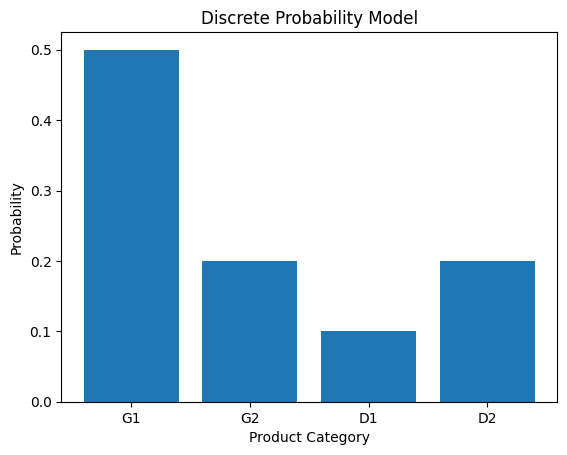

In [ ]:
import matplotlib.pyplot as plt

states = ['G1','G2','D1','D2']
probabilities = [0.50,0.20,0.10,0.20]

plt.bar(states, probabilities)

plt.xlabel('Product Category')
plt.ylabel('Probability')
plt.title('Discrete Probability Model')

plt.show()

# Q10) Information Available in Continuous Random Varaibles

A chemical plant monitors each production run using two different measurement systems.

For a given run, let

* $T$ be the deviation of the reactor temperature from target, measured in standardized units,
* $P$ be the deviation of the reactor pressure from target, also measured in standardized units.

Assume that $(T,P)$ is jointly continuous, with independent normal components:

$$
T \sim N(0,1), \qquad P \sim N(0,4),
$$

and $T$ and $P$ are independent.

Let the underlying probability space be

$$
\Omega=\mathbb R^2, \qquad \mathfrak F=\mathfrak B(\mathbb R^2),
$$

and let $P$ be the probability measure induced by the joint density

$$
f_{T,P}(t,p)=\frac{1}{4\pi}\exp\left(-\frac{t^2}{2}-\frac{p^2}{8}\right), \qquad (t,p)\in\mathbb R^2.
$$

Define two random variables on the same probability space:

* $X:\Omega\to\mathbb R$ by
  $$
  X(t,p)=t,
  $$
  so that $X$ records only the reactor temperature deviation;

* $Y:\Omega\to\mathbb R^2$ by
  $$
  Y(t,p)=(t,p),
  $$
  so that $Y$ records the full sensor state: both temperature and pressure deviations.

Answer the following.

1. Write down the probability space $(\Omega,\mathfrak F,P)$ explicitly.

2. Compute the $\sigma$-algebra generated by $X$, namely $\sigma(X)$.

3. Compute the $\sigma$-algebra generated by $Y$, namely $\sigma(Y)$.

4. Show that
   $$
   \sigma(X)\subseteq \sigma(Y),
   $$
   and explain why $Y$ contains more information than $X$.

5. Find the marginal density of $X$.

6. Find the marginal density of $Y$.

7. Compute the following probabilities:
   $$
   P(X\leq 0), \qquad P(X>1), \qquad P(Y\in (-\infty,0]\times\mathbb R), \qquad P(Y\in [ -1,1]\times[-2,2]).
   $$

8. Compute the conditional distribution of $X$ given $Y=(t,p)$.

9. Compute the conditional distribution of $Y$ given $X=t$.

10. Explain, in words, what is known when one conditions on $X$ and what additional information becomes available when one conditions on $Y$.

11. Show that
    $$
    X=\pi_1\circ Y,
    $$
    where $\pi_1(t,p)=t$, and explain why this implies that $X$ is a measurable function of $Y$.

12. Give a Python-based visualization of the model, for example by plotting:

* the joint density of $Y=(T,P)$ as a contour plot or heat map;
* the marginal density of $X$;
* and a diagram illustrating that $\sigma(X)$ is coarser than $\sigma(Y)$.

###Answer 10
1.
Ω=$R^2$

$F=B(R^2)$

Probability measure induced by

$f_{T,P}(t,p)=(1/{4π})exp(−t^2/2-p^2/8)$


2.
σ(X)={X−1(B):B∈B(R)}


3.
σ(Y)=B($R^2$)


4.
Because $X=π_1∘Y$

where
$π_1(t,p)=t$

X is a measurable function of Y.

Therefore,
σ(X)⊆σ(Y)
	​
Hence Y contains more information.

5.
Integrating out p:
$f_X(t)=(1/\sqrt{2π})e^{-t^2/2}$

Thus,

X∼N(0,1)

6.
$f_y(t,p)=(1/{4π})exp(-t^2/2-p^2/8)$


7.
P(X≤0)=0.5

P(X>1)=0.1587

Also,

P(Y∈(−∞,0]×R)=0.5

Using independence,

P(Y∈[−1,1]×[−2,2])=P(−1≤T≤1)P(−2≤P≤2)
=(0.6827)(0.6827)
≈0.466


8.
Given the full state Y=(t,p),

X=t

with probability 1.

Thus the conditional distribution is degenerate at t.

9.
Given X=t,

temperature is fixed,
pressure remains random:
P∼N(0,4)

Hence

Y∣X=t=(t,P)

10.
Conditioning on X:

only temperature information is known.

Conditioning on Y:

both temperature and pressure deviations are known.

Thus Y provides a more detailed sensor state.

11.
X=$π_1$∘Y

where
$π_1(t,p)=t$

Since $π_1$ is measurable, X is measurable with respect to Y.

Hence:

σ(X)⊆σ(Y)

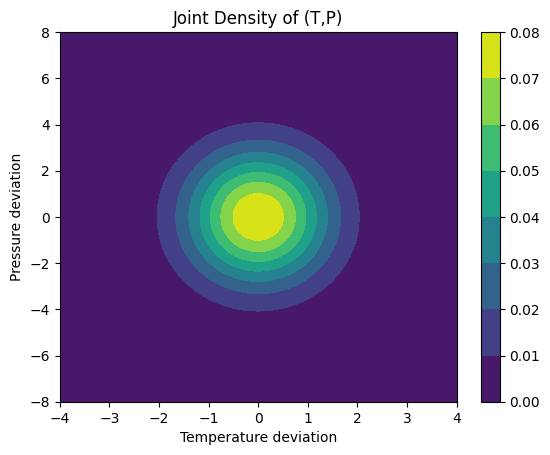

In [ ]:

from scipy.stats import multivariate_normal

# grid
x = np.linspace(-4,4,200)
y = np.linspace(-8,8,200)

X, Y = np.meshgrid(x, y)

pos = np.dstack((X, Y))

# covariance matrix
rv = multivariate_normal([0,0], [[1,0],[0,4]])

Z = rv.pdf(pos)

# contour plot
plt.contourf(X, Y, Z)

plt.xlabel('Temperature deviation')
plt.ylabel('Pressure deviation')

plt.title('Joint Density of (T,P)')

plt.colorbar()

plt.show()